In [7]:
import pandas as pd

import matplotlib.pyplot as plt

df_b1 = pd.read_csv("../data/processed/bioshock_1_themed.csv")
df_b2 = pd.read_csv("../data/processed/bioshock_2_themed.csv")
df_inf = pd.read_csv("../data/processed/bioshock_infinite_themed.csv")

print(len(df_b1), len(df_b2), len(df_inf))

print(df_b1["technical"].dtype)

26155 12008 47232
bool


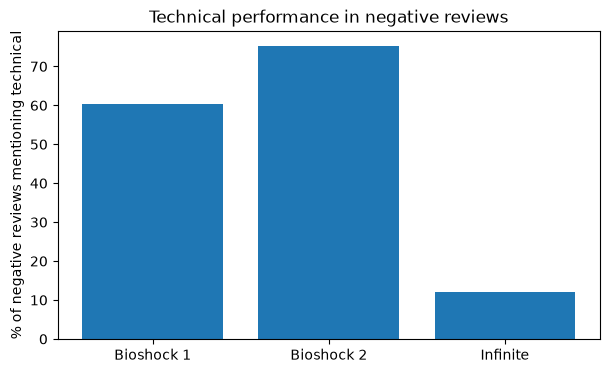

[np.float64(60.5), np.float64(75.3), np.float64(12.0)]


In [10]:
games = ["Bioshock 1", "Bioshock 2", "Infinite"]
neg_pct = [
    df_b1[df_b1["voted_up"] == False]["technical"].mean() *100,
    df_b2[df_b2["voted_up"] == False]["technical"].mean() *100,
    df_inf[df_inf["voted_up"] == False]["technical"].mean() *100,
]

fig, ax = plt.subplots(figsize= (7, 4))
ax.bar(games, neg_pct)
ax.set_ylabel("% of negative reviews mentioning technical")
ax.set_title("Technical performance in negative reviews")
plt.show()

print([round(p, 1) for p in neg_pct])

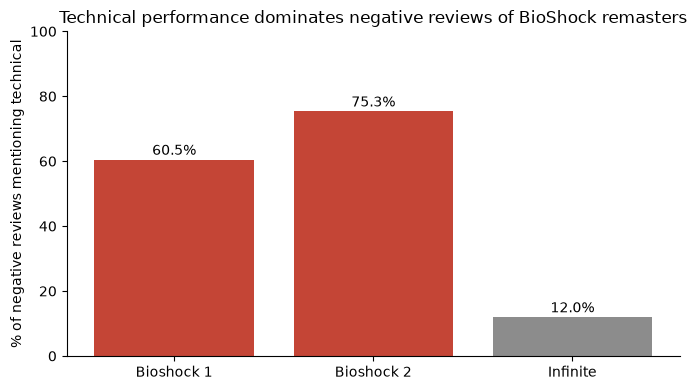

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(games, neg_pct, color=["#c44536", "#c44536", "#8c8c8c"])

for bar, pct in zip(bars, neg_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, pct + 1.5, f"{pct:.1f}%", ha="center")

ax.set_ylabel("% of negative reviews mentioning technical")
ax.set_title("Technical performance dominates negative reviews of BioShock remasters")
ax.set_ylim(0, 100)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [26]:
plt.savefig("../outputs/figures/f2_technical_negatives.png", dpi=200)

<Figure size 640x480 with 0 Axes>

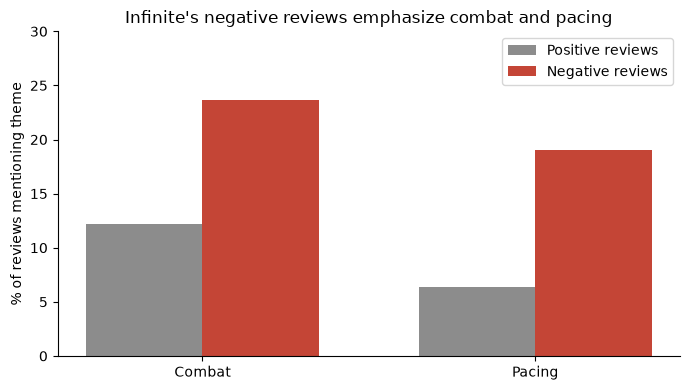

[np.float64(12.21602787456446), np.float64(6.341463414634147)] [np.float64(23.625059780009565), np.float64(19.03395504543281)]


In [29]:
inf_pos = df_inf[df_inf["voted_up"] == True]
inf_neg = df_inf[df_inf["voted_up"] == False]

pos_pct_inf = [inf_pos["combat"].mean() * 100, inf_pos["pacing"].mean() * 100]
neg_pct_inf = [inf_neg["combat"].mean() * 100, inf_neg["pacing"].mean() * 100]

x = [0, 1]
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([0 - width/2, 1 - width/2], pos_pct_inf, width, label = "Positive reviews", color = "#8c8c8c")
ax.bar([0 + width/2, 1 + width/2], neg_pct_inf, width, label="Negative reviews", color="#c44536")

ax.set_xticks(x)
ax.set_xticklabels(["Combat", "Pacing"])
ax.set_ylabel("% of reviews mentioning theme")
ax.set_title("Infinite's negative reviews emphasize combat and pacing")
ax.set_ylim(0, 30)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../outputs/figures/f4_infinite_combat_pacing.png", dpi=200)
plt.show()

print(pos_pct_inf, neg_pct_inf)